# Hypothesis Testing

The goal of this analysis is to evaluate the effectiveness of personalized email messaging in driving user conversions, comparing it to generic upsell emails. By conducting A/B testing and performing statistical analysis, the study aims to identify whether personalized messaging leads to higher conversion rates across different language segments, providing insights for optimizing email marketing strategies.

**Main Hypothesis:** I hypothesize that personalized messaging in emails will lead to a significant improvement in user conversions compared to generic upsell emails.

**Null Hypothesis (H₀):** Personalized messaging has no impact on conversions compared to generic upsell emails.

**Alternative Hypothesis (H₁):** Personalized messaging has a significant impact on conversions compared to generic upsell emails.

In [1]:
# Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read marketing data from CSV, parse dates
marketing = pd.read_csv("/content/drive/MyDrive/Marketing Analytics in Python\
/Analysing Marketing Campaigns with python\
/marketing.csv",
parse_dates=['date_served', 'date_subscribed', 'date_canceled'],
date_format='%m/%d/%y')

# Test allocation

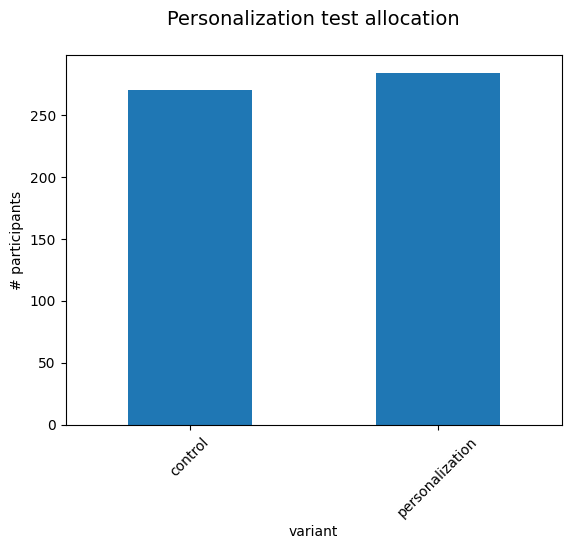

In [2]:
# Subset the DataFrame
email = marketing[marketing['marketing_channel']=='Email']

# Group the email DataFrame by variant
alloc = email.groupby('variant')['user_id'].nunique()

# Plot a bar chart of the test allocation
alloc.plot(kind='bar')
plt.title('Personalization test allocation\n', size=14, )
plt.ylabel('# participants')
plt.tick_params(axis='x', rotation=45)
plt.show()

In [3]:
# Group marketing by user_id and variant
subscribers = email.groupby(['user_id', 'variant'])['converted'].max()

subscribers_df = pd.DataFrame(subscribers.unstack(level=1))

# Drop missing values from the control column
control = subscribers_df['control'].dropna()

# Drop missing values from the personalization column
personalization = subscribers_df['personalization'].dropna()

print('Control conversion rate:', np.mean(control))
print('Personalization conversion rate:', np.mean(personalization))

control = pd.to_numeric(control, errors='coerce')
personalization = pd.to_numeric(personalization, errors='coerce')

Control conversion rate: 0.2814814814814815
Personalization conversion rate: 0.3908450704225352


In [4]:
# Calculating lift

def lift(a,b):
    # Calcuate the mean of a and b
    a_mean = np.mean(a)
    b_mean = np.mean(b)

    # Calculate the lift using a_mean and b_mean
    lift = (b_mean - a_mean)/a_mean

    return str(round(lift*100, 2)) + '%'

# Print lift() with control and personalization as inputs
print(lift(control, personalization))

38.85%


**Lift Calculation:** The `lift` function calculates the percentage increase in the conversion rate of the personalization group compared to the control group.  A positive lift indicates an improvement due to personalization messaging.

# Perform T-test

In [5]:
# perform T-test
from scipy.stats import ttest_ind

ttest_ind(control, personalization)

TtestResult(statistic=-2.734329944750507, pvalue=0.0064514878446941815, df=552.0)





**Interpreting the P-value:**

* **P-value < 0.05 (Significance Level):**  If the p-value is less than 0.05, we reject the null hypothesis. This means there's strong evidence that the difference in conversion rates between the two groups is statistically significant.  I can conclude that personalized email messaging *does* have a significant impact on conversions.


# A/B testing & Segemention:

It is important to check how new features are affecting specific demographics. Sometimes features that are highly appealing to one group are less appealing to others.

In [6]:
def ab_segmentation(segment):

  # Build a for loop for each subsegment in marketing
  for subsegment in np.unique(marketing[segment].values):
      print(subsegment)

      # Limit marketing to email and subsegment
      email = marketing[(marketing['marketing_channel'] == 'Email') & (marketing[segment] == subsegment)]

      subscribers = email.groupby(['user_id', 'variant'])['converted'].max()
      subscribers = pd.DataFrame(subscribers.unstack(level=1))
      control = subscribers['control'].dropna()
      personalization = subscribers['personalization'].dropna()

      control = pd.to_numeric(control, errors='coerce')
      personalization = pd.to_numeric(personalization, errors='coerce')

      print('lift:', lift(control, personalization))
      print('t-statistic:', ttest_ind(control, personalization), '\n\n')

In [7]:
# Use ab_segmentation on language displayed
ab_segmentation('language_displayed')

Arabic
lift: 50.0%
t-statistic: TtestResult(statistic=-0.5773502691896255, pvalue=0.5795840000000001, df=8.0) 


English
lift: 39.0%
t-statistic: TtestResult(statistic=-2.2183598646203215, pvalue=0.026991701290720503, df=486.0) 


German
lift: -1.62%
t-statistic: TtestResult(statistic=0.19100834180787182, pvalue=0.8494394170062678, df=42.0) 


Spanish
lift: 166.67%
t-statistic: TtestResult(statistic=-2.3570226039551585, pvalue=0.040156718110477524, df=10.0) 




/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


# Key Findings

Personalized emails significantly improve conversions `(positive lift)`, supported by a statistically significant t-test `(p<0.05)`, rejecting the null hypothesis.  Further segmentation by language displayed indicates that `Spanish (166.67% lift, p = 0.0402)` and `English (39.0% lift, p = 0.0270)` show statistically significant improvements, suggesting meaningful changes. In contrast, `Arabic (50.0% lift, p = 0.5796)` and `German (-1.62% lift, p = 0.8494)` have high p-values, indicating no significant effect.
